## 📓 Notebook 05: Stats & Plots

**Skills practiced:** NumPy array math (no loops), rolling averages, 
z-score outlier detection, `np.corrcoef()`, matplotlib.

**Goal:** Compute a rolling 3-year valence average, flag outlier songs via 
z-score, build a correlation matrix across valence/energy/tempo/danceability, 
and produce the final rolling-average plot.

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv('../data/processed/merged_data.csv')

#sort the dataframe by year
df.sort_values(by=['year', 'valence'], inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(df.head(5))

   year  rank                title artists                track_id  \
0  2001    14     it's been awhile  staind  1BExV8JprNJLvLeDE9qdEW   
1  2001    14     it's been awhile  staind  1BExV8JprNJLvLeDE9qdEW   
2  2001    39  with arms wide open   creed  2cJDsHTLgDQvf5G73RCNX5   
3  2001    39  with arms wide open   creed  2YHIP0JrmNPJxwuUE45o7l   
4  2001    39  with arms wide open   creed  2cJDsHTLgDQvf5G73RCNX5   

          album_name  popularity track_genre  danceability  energy  loudness  \
0    Break the Cycle        65.0      grunge         0.509   0.774    -4.054   
1    Break the Cycle        65.0       metal         0.509   0.774    -4.054   
2  Father's Day 2020        56.0      grunge         0.415   0.533    -8.445   
3    Throwback Songs        43.0      grunge         0.415   0.533    -8.445   
4  Father's Day 2020        56.0       metal         0.415   0.533    -8.445   

     tempo  valence  speechiness  
0  116.529   0.0824       0.0338  
1  116.529   0.0824       0.

In [108]:
valence_mean=df['valence'].rolling(3).mean().to_numpy()
print(valence_mean)

[       nan        nan 0.09693333 ... 0.92833333 0.943      0.945     ]


In [109]:
valence_zscore=(df['valence']-valence_mean)/df['valence'].rolling(3).std().to_numpy()
print(valence_zscore.describe())
print(valence_zscore.isna().sum())
print(valence_zscore.head(5))

count    737.000000
mean       0.741669
std        0.500863
min       -1.154701
25%        0.577350
50%        0.832050
75%        1.154701
max        1.154701
Name: valence, dtype: float64
653
0         NaN
1         NaN
2    1.154701
3    0.577350
4         NaN
Name: valence, dtype: float64


In [110]:
outliners = np.abs(valence_zscore) > 1 #if set to 2 it becomes Index: []
outliners = df[outliners]
print(len(df))
print(outliners)

1390
      year  rank                              title           artists  \
2     2001    39                with arms wide open             creed   
5     2001    99                               hero  enrique iglesias   
6     2001    76                             austin     blake shelton   
8     2001    40  case of the ex (whatcha gonna do)               mýa   
9     2001    44                         kryptonite      3 doors down   
...    ...   ...                                ...               ...   
1339  2023    84                     last christmas             wham!   
1341  2025    67  rockin' around the christmas tree        brenda lee   
1384  2025    67  rockin' around the christmas tree        brenda lee   
1386  2025    65                     last christmas             wham!   
1388  2025    65                     last christmas             wham!   

                    track_id  \
2     2cJDsHTLgDQvf5G73RCNX5   
5     1PAgmT6YqGhd6zT9kN9gIo   
6     2hyP9WkqwrydvQZ7

In [111]:
correlation_matrix = np.corrcoef([df['valence'], df['energy'], df['danceability'], df['tempo']])
df_correlation_matrix = pd.DataFrame(correlation_matrix, index=['valence', 'energy', 'danceability', 'tempo'], columns=['valence', 'energy', 'danceability', 'tempo'])
print(df_correlation_matrix)

               valence    energy  danceability     tempo
valence       1.000000  0.218351      0.334607 -0.315621
energy        0.218351  1.000000     -0.096107  0.157639
danceability  0.334607 -0.096107      1.000000 -0.305622
tempo        -0.315621  0.157639     -0.305622  1.000000


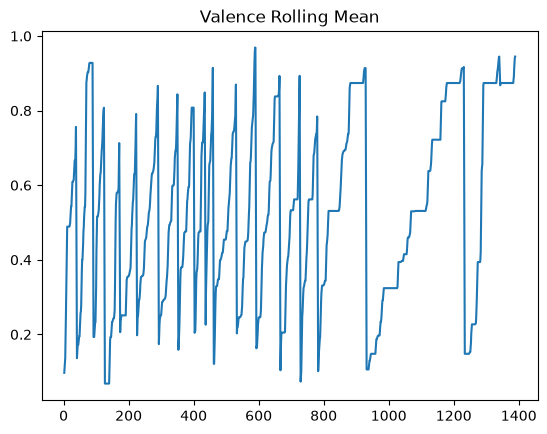

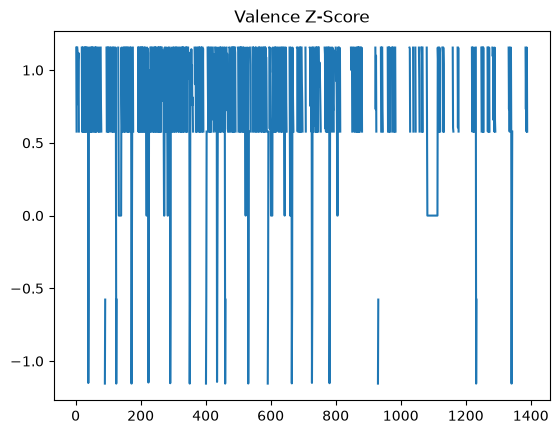

In [113]:
plt.plot(valence_mean)
plt.title('Valence Rolling Mean')
plt.show()
plt.plot(valence_zscore)
plt.title('Valence Z-Score')
plt.show()